# KNN 血糖预测模型 (K-Nearest Neighbors)

本 Notebook 实现了一个基于 K-Nearest Neighbors (KNN) 算法的血糖预测模型。该模型利用历史血糖数据以及患者的静态特征（年龄、BMI）来预测未来的血糖水平。

## **主要流程**

1.  **数据加载**:
    *   读取预处理后的训练集 (`Train.csv`) 和测试集 (`Test.csv`)。
    *   读取保留数据集 (`served.csv`) 用于模型的泛化能力评估。

2.  **特征工程 (Feature Engineering)**:
    *   **滑动窗口法**: 构建时序特征，使用过去 `N` 个时间步（例如 60 分钟）的血糖值作为输入。
    *   **多步直接预测**: 构造标签以预测未来特定时间步（例如 30 分钟或 60 分钟后）的血糖值。
    *   **特征融合**: 将动态的时序特征与静态特征（Age, BMI）及时间特征（Hour）相结合。

3.  **数据预处理**:
    *   使用 `StandardScaler` 对特征进行标准化处理，消除不同特征量纲的影响（这对基于距离的 KNN 算法尤为重要）。

4.  **模型训练**:
    *   使用 `KNeighborsRegressor` 进行回归预测。

5.  **模型评估**:
    *   **统计指标**: 计算 MAE, RMSE, MAPE, RMSPE 等指标评估预测准确性。
    *   **临床评估**: 使用 Clarke Error Grid Analysis (克拉克误差网格分析) 评估预测结果的临床安全性。
    *   **可视化**: 绘制预测曲线与真实值的对比图，以及误差分布图。

6.  **泛化能力测试**:
    *   在完全独立的 Served Set (保留数据集) 上进行测试，验证模型对未见过的受试者的预测能力。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set scientific plotting style (referencing filter_comparison.ipynb)
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [2]:
# 加载训练集和测试集
train_path = '../../DataSplit/TrainTest/Train.csv'
test_path = '../../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print("训练集形状:", df_train.shape)
print("测试集形状:", df_test.shape)
df_train.head()

训练集形状: (97814, 5)
测试集形状: (11808, 5)


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


In [3]:
def create_dataset(data, n_past, prediction_horizon=1):
    """
    创建滑动窗口数据集 (支持多步直接预测)
    
    参数:
    data: 包含 'id', 'gl', 'age', 'bmi' 列的 DataFrame
    n_past: 过去的时间步数 (滑动窗口大小)
    prediction_horizon: 预测未来第几个时间步 (默认为1)
    
    返回:
    X: 特征矩阵 (n_samples, n_features)
    y: 目标向量 (n_samples,) -> t + prediction_horizon 时刻的血糖值
    """
    X, y = [], []
    
    # 按受试者分组处理
    for subject_id, group in data.groupby('id'):
        gl_values = group['gl'].values
        age = group['age'].iloc[0] 
        bmi = group['bmi'].iloc[0] 
        
        # 确保数据足够长
        # 需要至少 n_past + prediction_horizon 个点才能构建一个样本
        if len(gl_values) < n_past + prediction_horizon:
            continue

        # 构建滑动窗口
        # 最后一个窗口的起始点 i 满足: i + prediction_horizon - 1 < len
        # 即 i < len - prediction_horizon + 1
        for i in range(n_past, len(gl_values) - prediction_horizon + 1):
            # 过去 n_past 个时间步的血糖值 [t-N, ..., t-1]
            past_gl = gl_values[i-n_past:i]
            
            # 特征向量: [gl_t-N, ..., gl_t-1, age, bmi]
            features = np.append(past_gl, [age, bmi])
            
            X.append(features)
            # 预测目标: t + horizon - 1 (因为 i 是 t 的索引)
            # 实际上 i 是窗口结束后的第一个索引 (t)
            # 我们想预测 t + horizon - 1 (相对于 t 的偏移)
            # 比如 horizon=1, 预测 gl_values[i]
            # horizon=6, 预测 gl_values[i+5]
            y.append(gl_values[i + prediction_horizon - 1])
            
    return np.array(X), np.array(y)

# 设定滑动窗口大小 (例如过去 12 个点，即 1 小时数据)
N_PAST = 12 
# 设定预测步长 (例如 4 个点，即 20 分钟)
PREDICTION_HORIZON = 6

print(f"正在构建滑动窗口数据集 (N_PAST={N_PAST}, Horizon={PREDICTION_HORIZON})...")
print(f"预测目标: 未来第 {PREDICTION_HORIZON} 个点 (即 {PREDICTION_HORIZON * 5} 分钟后)")

X_train, y_train = create_dataset(df_train, N_PAST, PREDICTION_HORIZON)
X_test, y_test = create_dataset(df_test, N_PAST, PREDICTION_HORIZON)

print(f"构建特征后的训练集形状: X={X_train.shape}, y={y_train.shape}")
print(f"构建特征后的测试集形状: X={X_test.shape}, y={y_test.shape}")

# --- 验证数据构造是否正确 ---
print("\n[数据构造验证]")
# 取第一个样本
sample_idx = 0
# 特征中的最后一点血糖值 (即 t-1 时刻)
last_input_gl = X_train[sample_idx][N_PAST-1] 
# 对应的目标值 (即 t + horizon - 1 时刻)
target_gl = y_train[sample_idx]

print(f"样本 {sample_idx}:")
print(f"  输入窗口最后一点血糖值 (t-5min): {last_input_gl}")
print(f"  预测目标血糖值 (t+{PREDICTION_HORIZON*5-5}min): {target_gl}")
print(f"  两者差值: {target_gl - last_input_gl:.2f}")
if PREDICTION_HORIZON > 1:
    print("  (注意：如果预测步长较大，目标值与最后输入值的差异通常会变大，这是正常的)")

正在构建滑动窗口数据集 (N_PAST=12, Horizon=6)...
预测目标: 未来第 6 个点 (即 30 分钟后)
构建特征后的训练集形状: X=(95026, 14), y=(95026,)
构建特征后的测试集形状: X=(9020, 14), y=(9020,)

[数据构造验证]
样本 0:
  输入窗口最后一点血糖值 (t-5min): 86.6542986425345
  预测目标血糖值 (t+25min): 82.45248868778333
  两者差值: -4.20
  (注意：如果预测步长较大，目标值与最后输入值的差异通常会变大，这是正常的)


In [4]:
# 数据标准化
# KNN 对距离敏感，必须对特征进行标准化
scaler = StandardScaler()

# 在训练集上拟合 scaler，并转换训练集
X_train_scaled = scaler.fit_transform(X_train)

# 使用训练集的 scaler 转换测试集 (避免数据泄露)
X_test_scaled = scaler.transform(X_test)

print("前5个样本的标准化特征 (部分展示):")
print(X_train_scaled[:5, :5]) # 展示前5行前5列

前5个样本的标准化特征 (部分展示):
[[-0.55385998 -0.540587   -0.53325759 -0.53125873 -0.53397404]
 [-0.5405221  -0.53316846 -0.53114537 -0.53383925 -0.54063338]
 [-0.53310496 -0.5310566  -0.53372546 -0.54049748 -0.55075562]
 [-0.5309935  -0.53363626 -0.5403826  -0.55061805 -0.56372529]
 [-0.53357267 -0.54029226 -0.5505015  -0.56358558 -0.57929214]]


In [5]:
# 构建 KNN 模型
# n_neighbors 是关键超参数，这里先设为 5，实际应用中可以通过交叉验证优化
knn_model = KNeighborsRegressor(n_neighbors=5)

# 训练模型
print("开始训练 KNN 模型...")
knn_model.fit(X_train_scaled, y_train)
print("模型训练完成。")

开始训练 KNN 模型...
模型训练完成。


In [6]:
# ============ 主流程：直接预测 ============

print("=" * 60)
print("🚀 直接预测方法 (Direct Prediction)")
print(f"预测步长: {PREDICTION_HORIZON} 步 ({PREDICTION_HORIZON * 5} 分钟)")
print("=" * 60)

# 1. 直接使用训练好的模型进行预测
# 注意：模型是在 create_dataset 指定的 Horizon 下训练的
print("\n[1/2] 正在对测试集进行预测...")
y_pred = knn_model.predict(X_test_scaled)
print(f"   ✓ 预测完成，共 {len(y_pred)} 个样本")

# 2. 计算评估指标
print("\n[2/2] 计算评估指标...")

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return mae, rmse, mape, rmspe

mae, rmse, mape, rmspe = calculate_metrics(y_test, y_pred)

print("\n" + "=" * 60)
print(f"📊 直接预测评估结果 (Horizon={PREDICTION_HORIZON}, {PREDICTION_HORIZON*5} mins)")
print("=" * 60)
print(f"MAE:   {mae:.4f} mg/dL")
print(f"RMSE:  {rmse:.4f} mg/dL")
print(f"MAPE:  {mape:.4f}%")
print(f"RMSPE: {rmspe:.4f}%")
print("=" * 60)

🚀 直接预测方法 (Direct Prediction)
预测步长: 6 步 (30 分钟)

[1/2] 正在对测试集进行预测...
   ✓ 预测完成，共 9020 个样本

[2/2] 计算评估指标...

📊 直接预测评估结果 (Horizon=6, 30 mins)
MAE:   8.8462 mg/dL
RMSE:  12.2451 mg/dL
MAPE:  8.0458%
RMSPE: 10.6412%


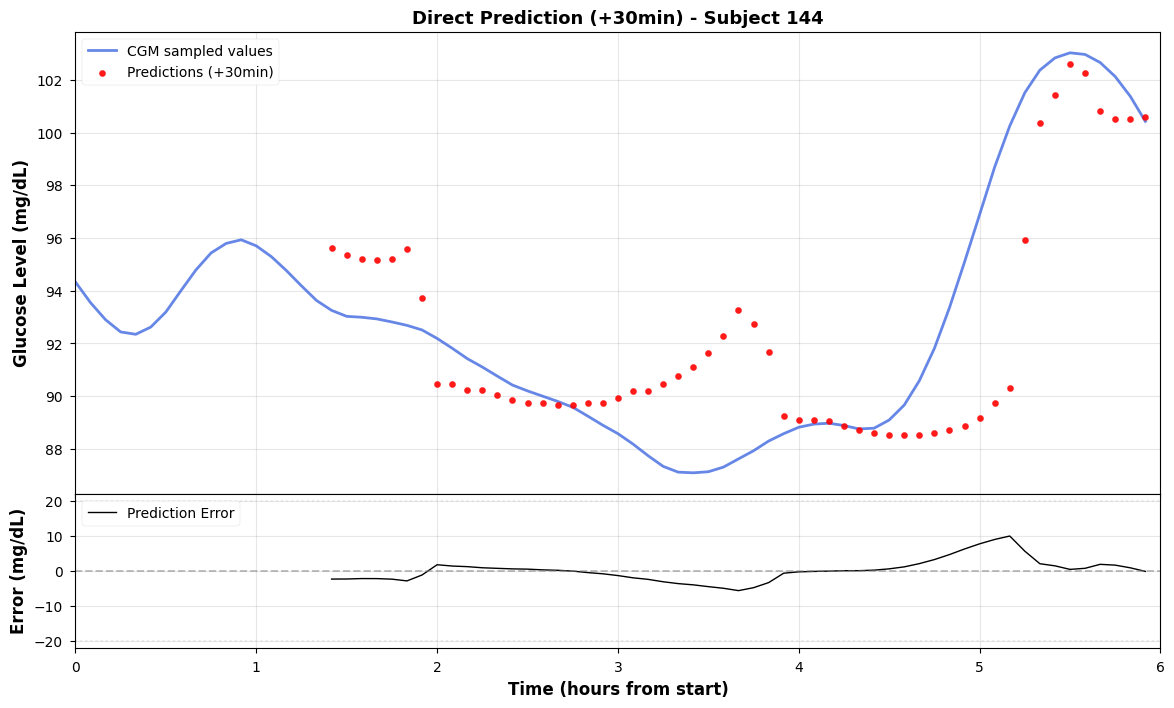

Subject 144 (MAPE 2.44%): Visualization generated.


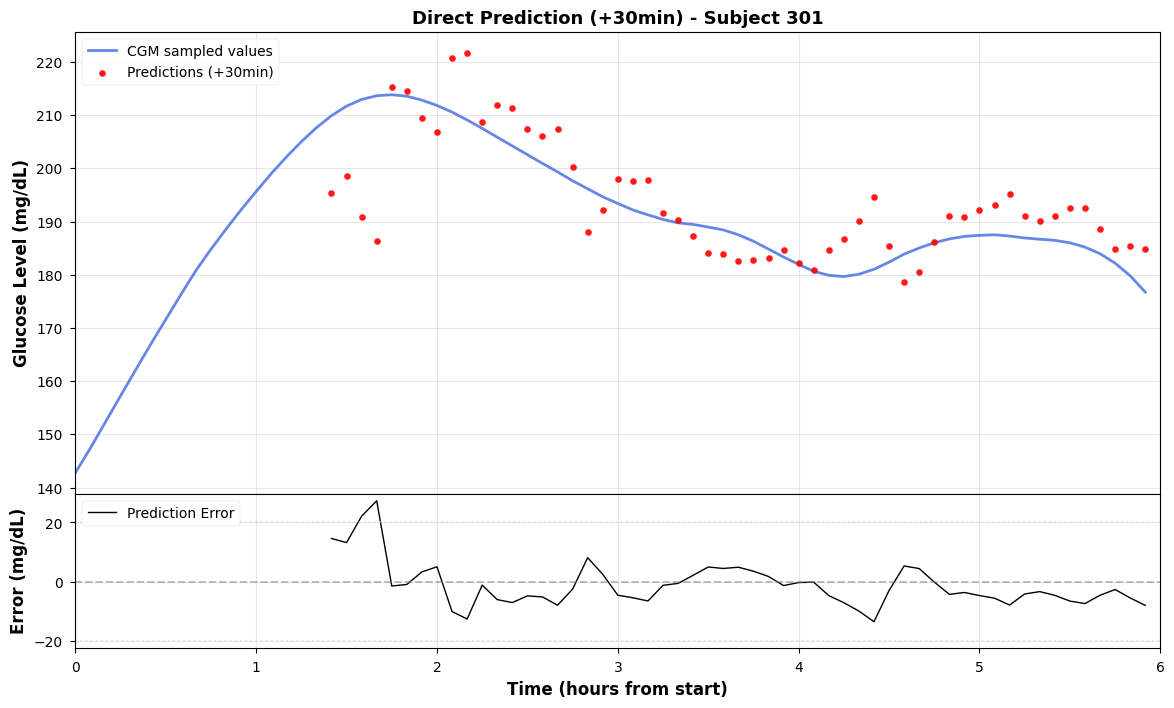

Subject 301 (MAPE 2.97%): Visualization generated.


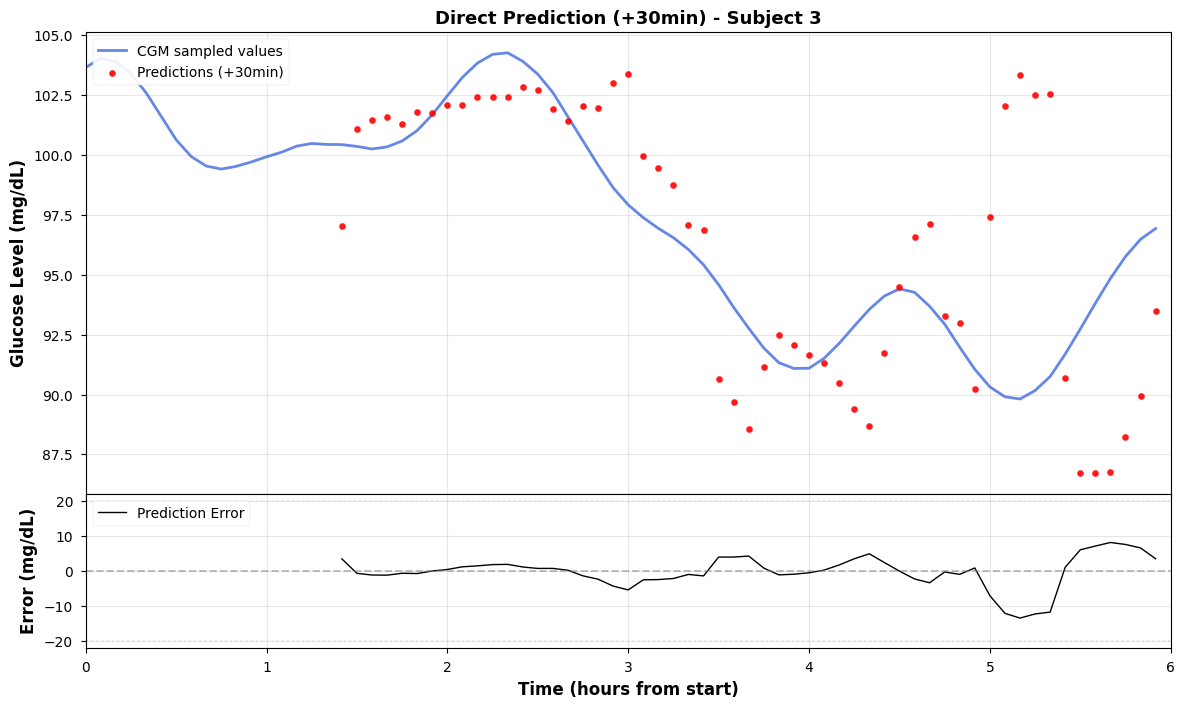

Subject 3 (MAPE 3.35%): Visualization generated.


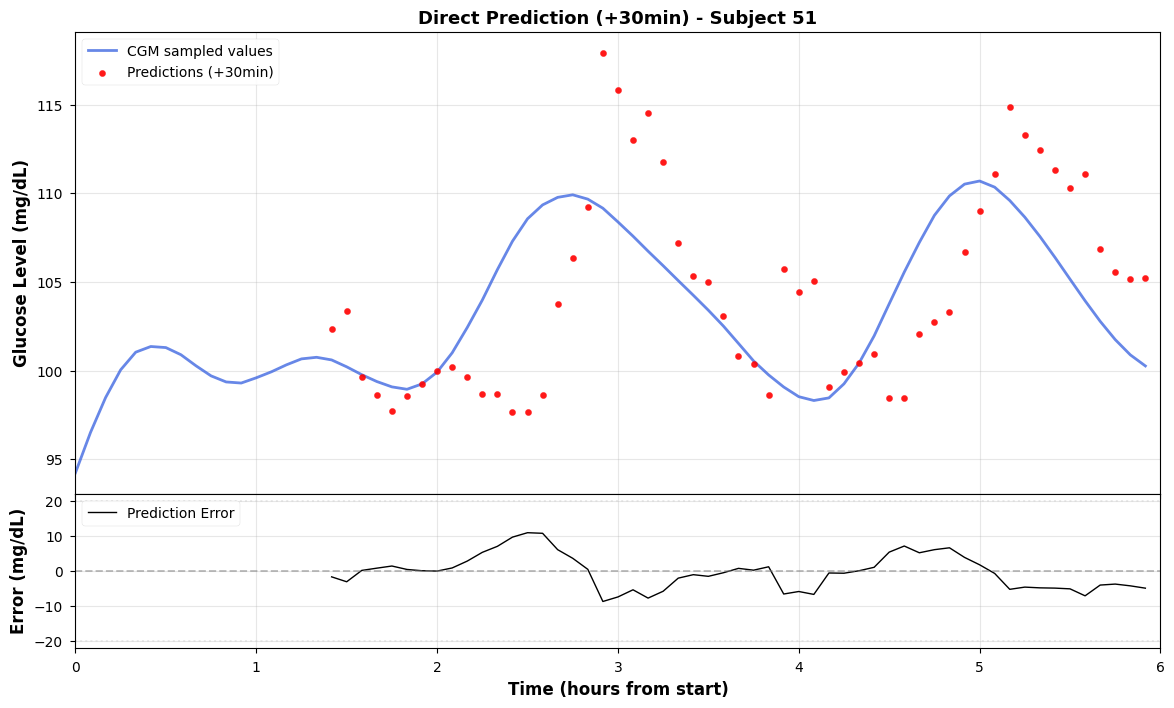

Subject 51 (MAPE 3.70%): Visualization generated.


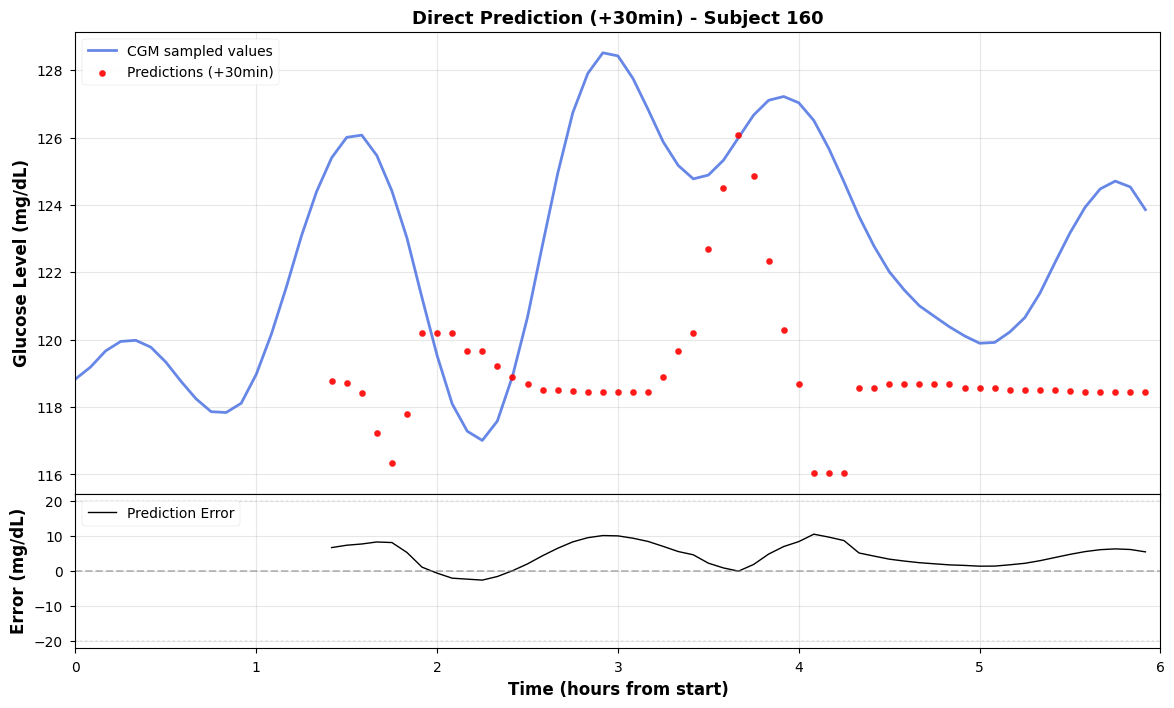

Subject 160 (MAPE 3.82%): Visualization generated.


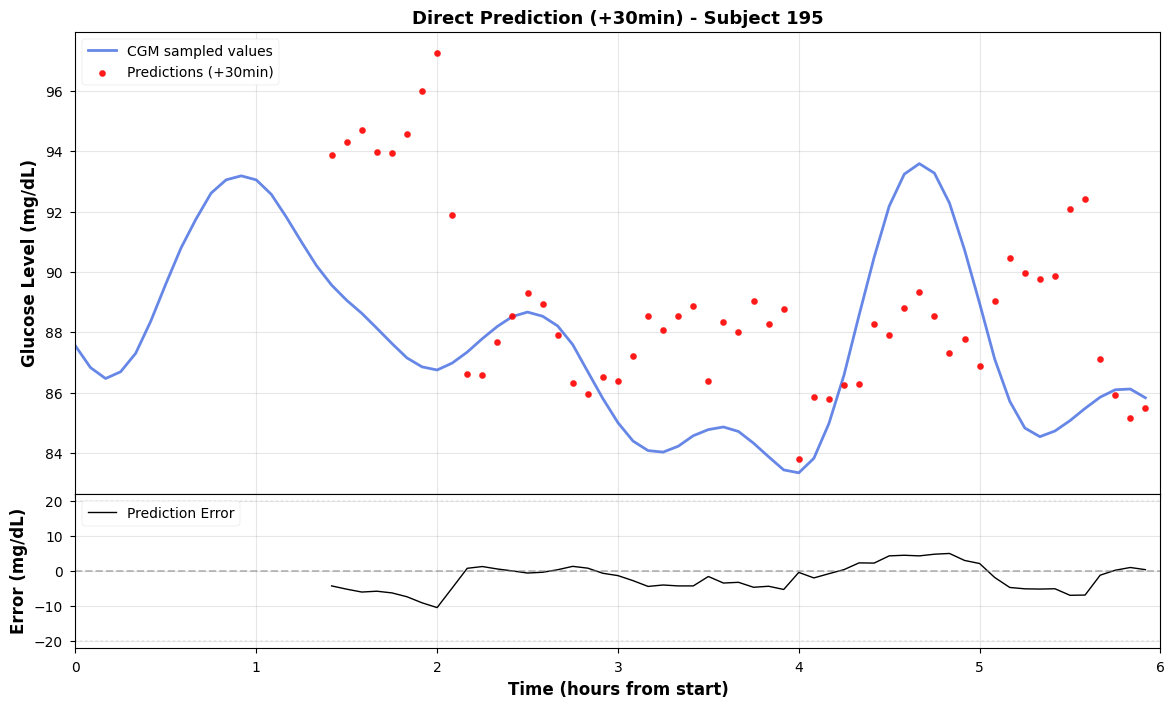

Subject 195 (MAPE 3.87%): Visualization generated.


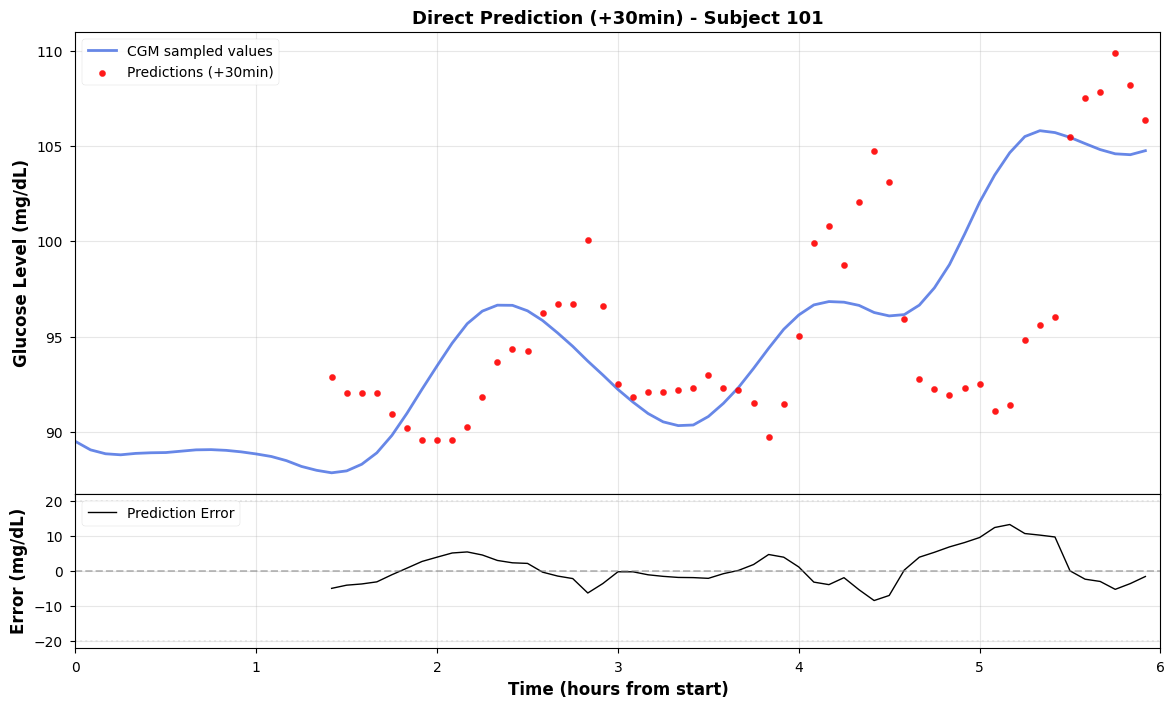

Subject 101 (MAPE 4.05%): Visualization generated.


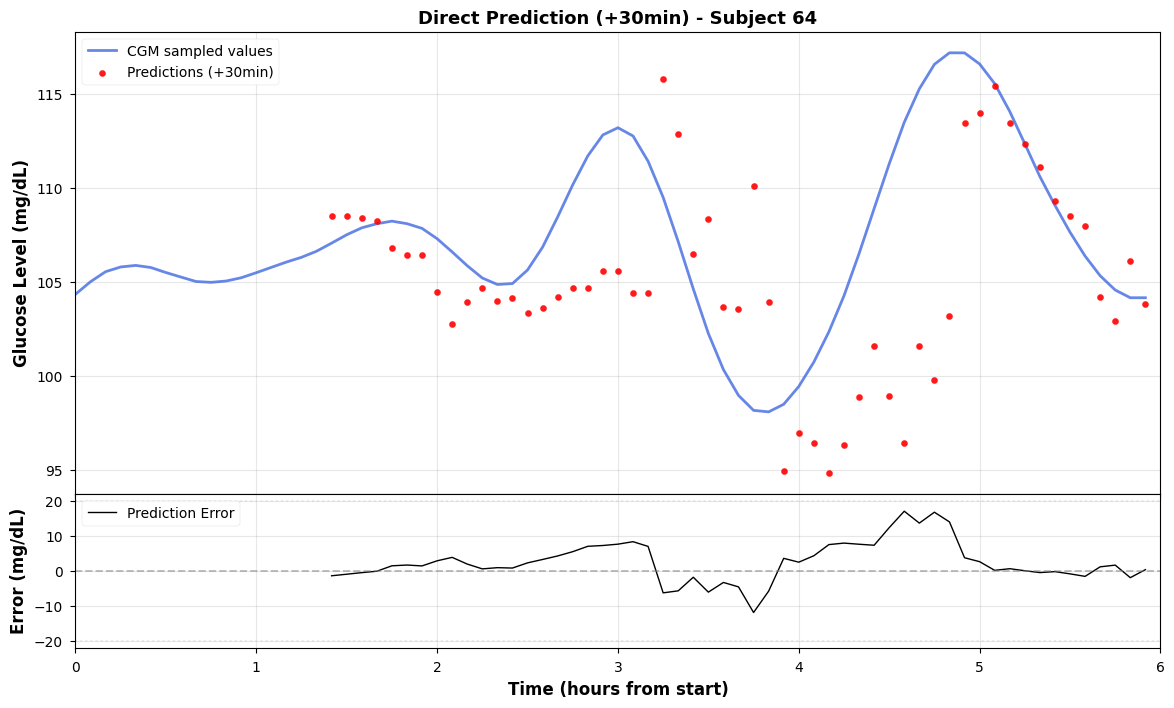

Subject 64 (MAPE 4.11%): Visualization generated.


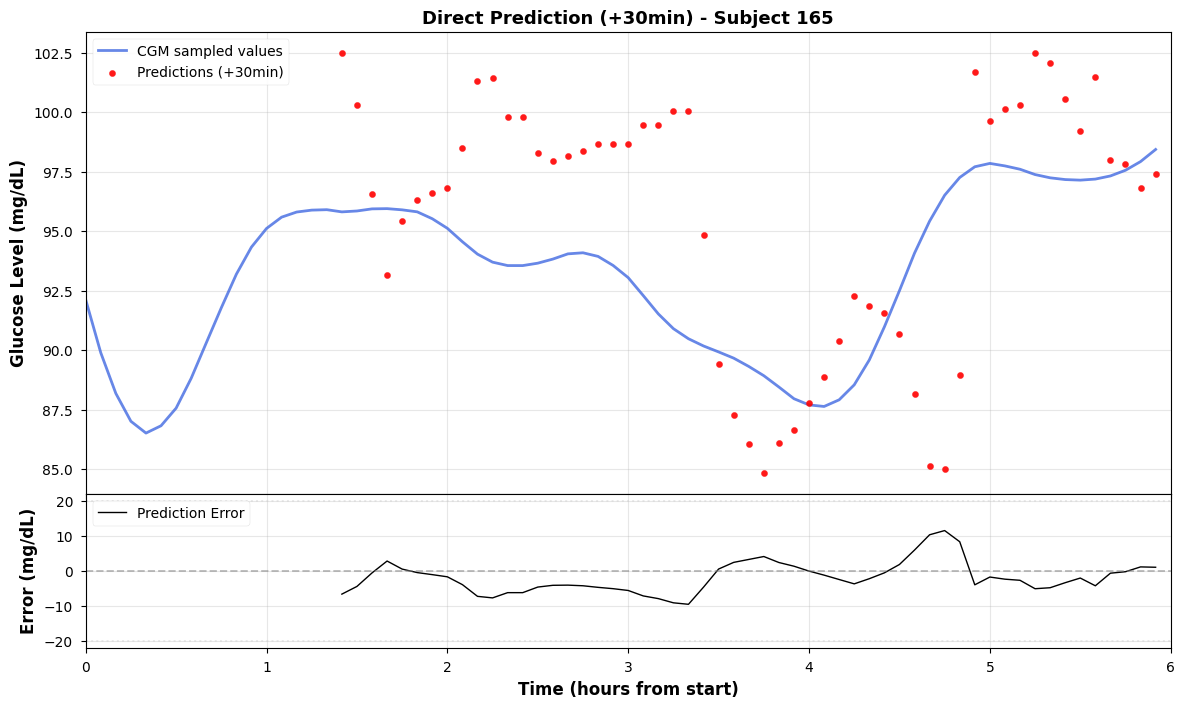

Subject 165 (MAPE 4.20%): Visualization generated.


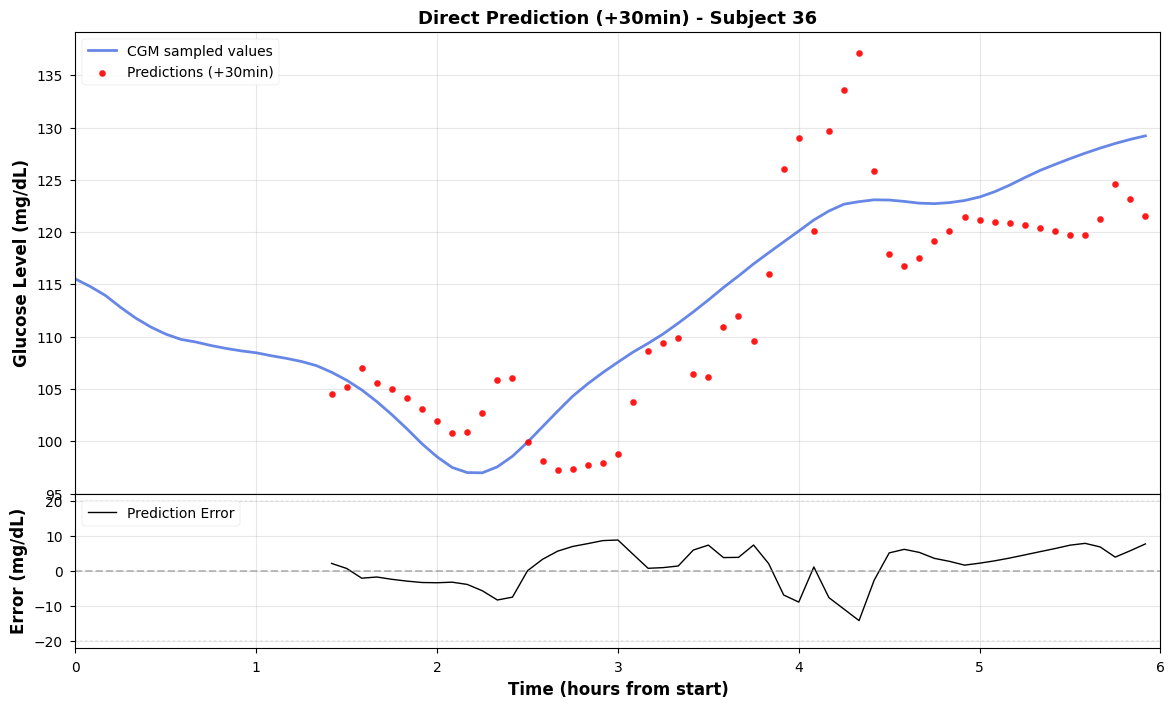

Subject 36 (MAPE 4.25%): Visualization generated.


In [7]:
import matplotlib.dates as mdates

# 获取测试集中所有受试者的 ID（已排序）
subject_ids = sorted(df_test['id'].unique())

# 先计算每个受试者的 MAPE，用于挑选前 10 名
subject_stats = []

# 我们需要重新对齐预测值到受试者
# y_pred 是所有受试者有效样本的拼接
# 我们需要知道每个受试者有多少个有效样本

current_pred_idx = 0

for subject_id in subject_ids:
    # 提取该受试者数据
    subject_data = df_test[df_test['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    # 计算该受试者的有效样本数 (与 create_dataset 逻辑一致)
    # 有效样本数 = len - n_past - horizon + 1
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    
    if n_valid <= 0:
        continue

    # 提取该受试者的预测值
    y_pred_subj = y_pred[current_pred_idx : current_pred_idx + n_valid]
    
    # 真实值: 从 N_PAST + HORIZON - 1 开始
    y_true_subj = gl_values[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + n_valid]
    
    current_pred_idx += n_valid

    # 计算 MAPE
    mask = y_true_subj != 0
    if mask.any():
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
    else:
        mape_subj = np.nan

    subject_stats.append({
        'id': subject_id,
        'mape': mape_subj,
        'data': subject_data,
        'y_true': y_true_subj,
        'y_pred': y_pred_subj,
    })

# 按 MAPE 升序取前 10 个受试者
subject_stats = [s for s in subject_stats if not np.isnan(s['mape'])]
subject_stats = sorted(subject_stats, key=lambda x: x['mape'])[:10]

# 绘图
for stat in subject_stats:
    subject_id = stat['id']
    subject_data = stat['data']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    error = y_true_subj - y_pred_subj

    # 构造时间轴
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    # 预测值对应的时间点
    pred_hours = full_hours[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + len(y_pred_subj)]

    y_true_full = subject_data['gl'].values

    # 绘图
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    ax1.plot(full_hours, y_true_full, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_subj, label=f'Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'Direct Prediction (+{PREDICTION_HORIZON*5}min) - Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    ax2.set_xlim(0, 6)

    plt.show()
    print(f"Subject {subject_id} (MAPE {stat['mape']:.2f}%): Visualization generated.")

Served 数据集加载完成，形状: (7944, 5)
正在构建 Served Set 数据集...
Served Set 样本数: 7774
正在对 Served Set 进行预测...
------------------------------
Served Set 评估结果 (Horizon=6):
MAE: 11.3252 mg/dL
RMSE: 15.6312 mg/dL
MAPE: 9.9544%
RMSPE: 13.6284%
------------------------------


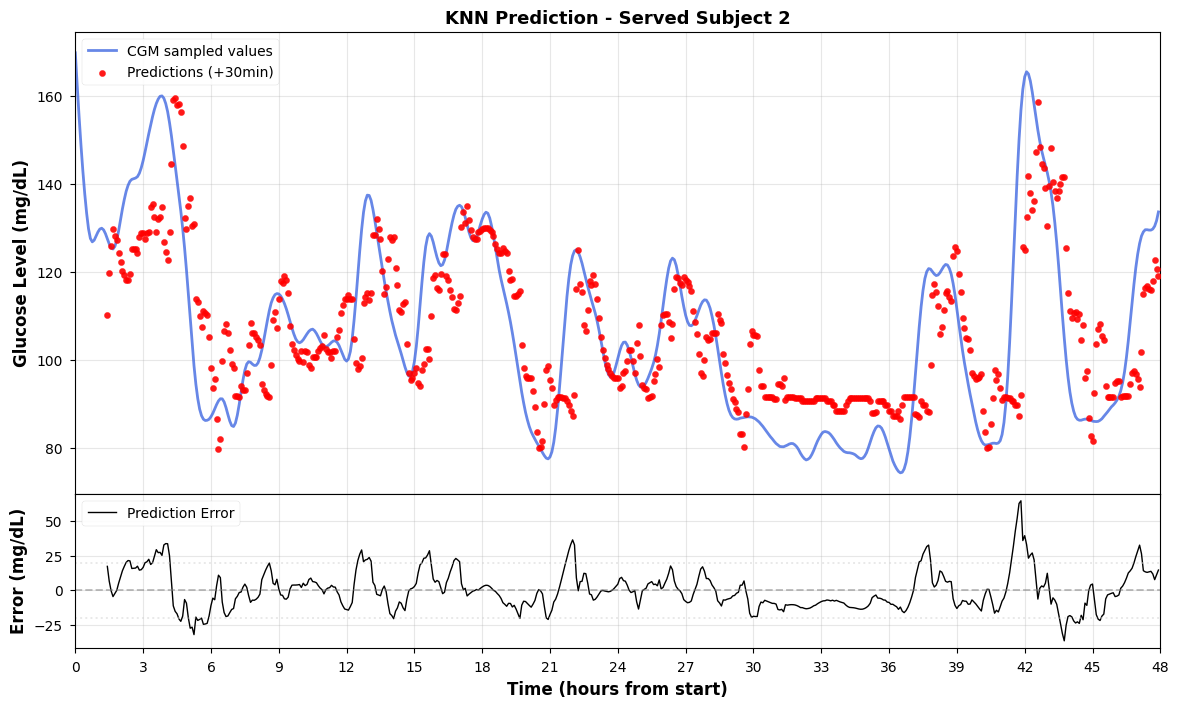

Served Subject 2: Visualization generated.


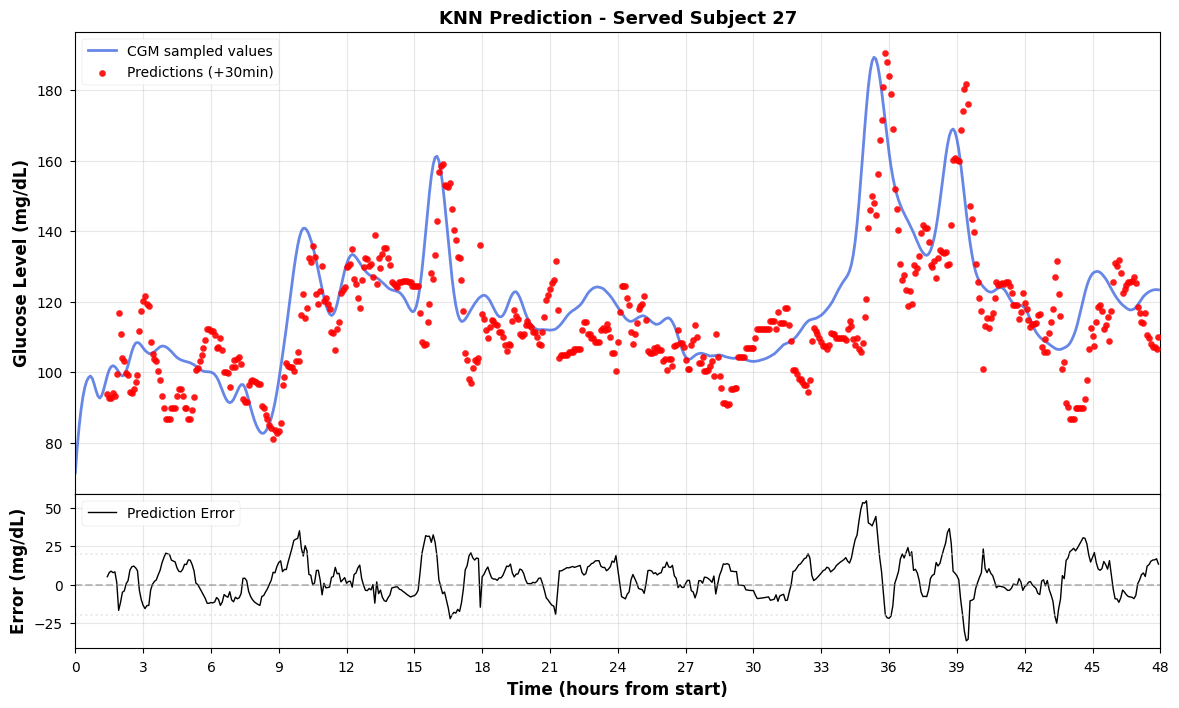

Served Subject 27: Visualization generated.


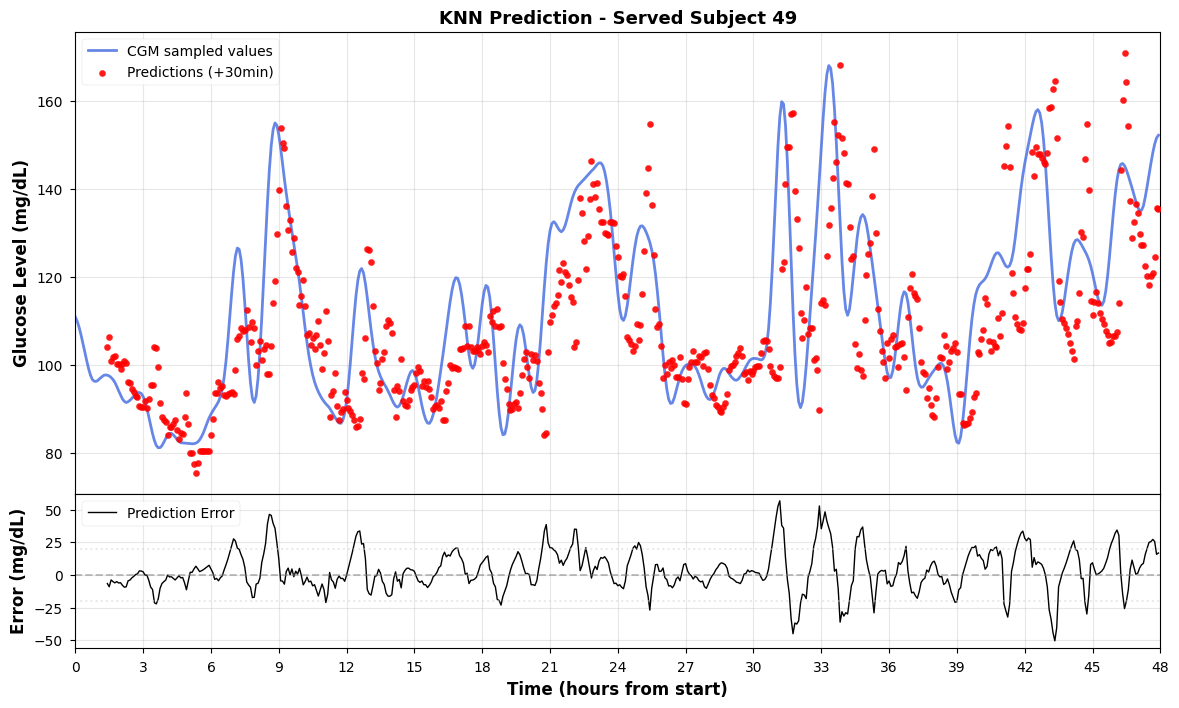

Served Subject 49: Visualization generated.


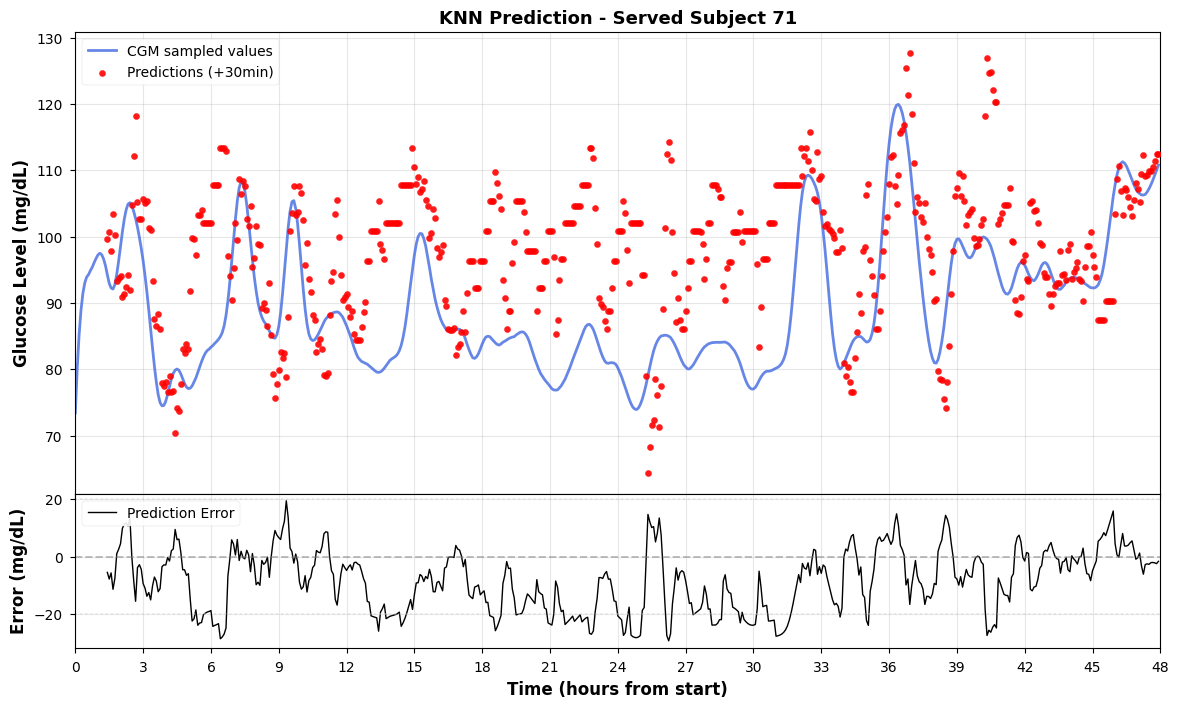

Served Subject 71: Visualization generated.


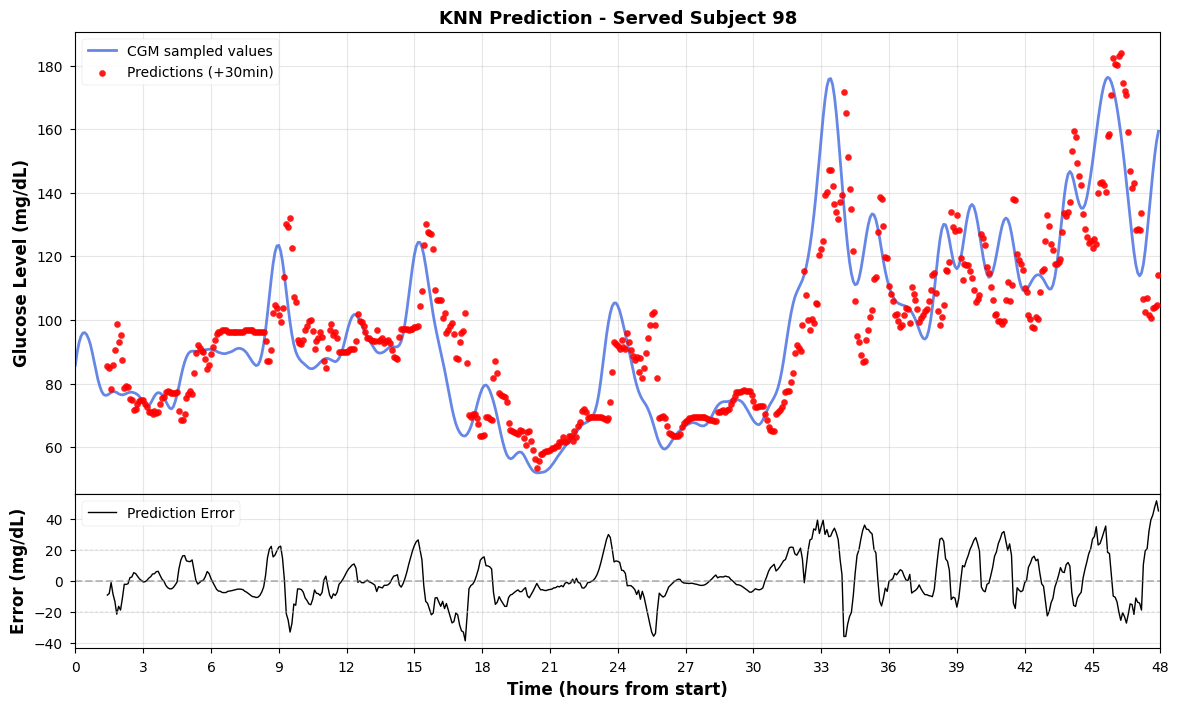

Served Subject 98: Visualization generated.


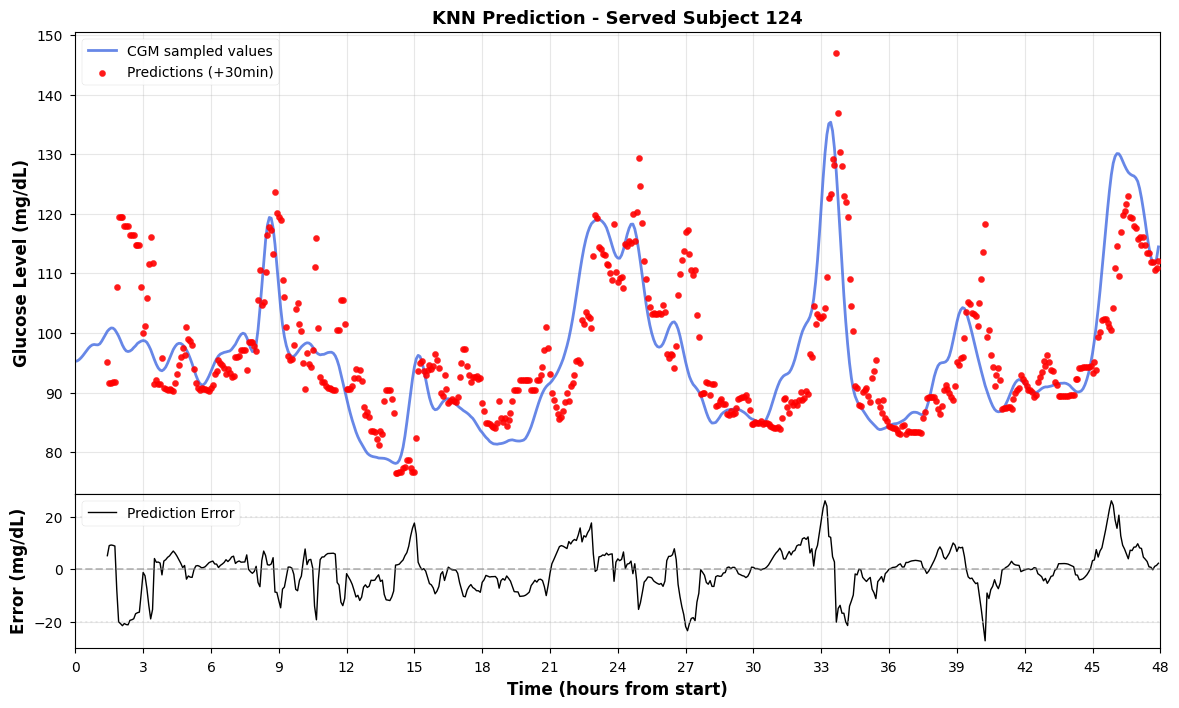

Served Subject 124: Visualization generated.


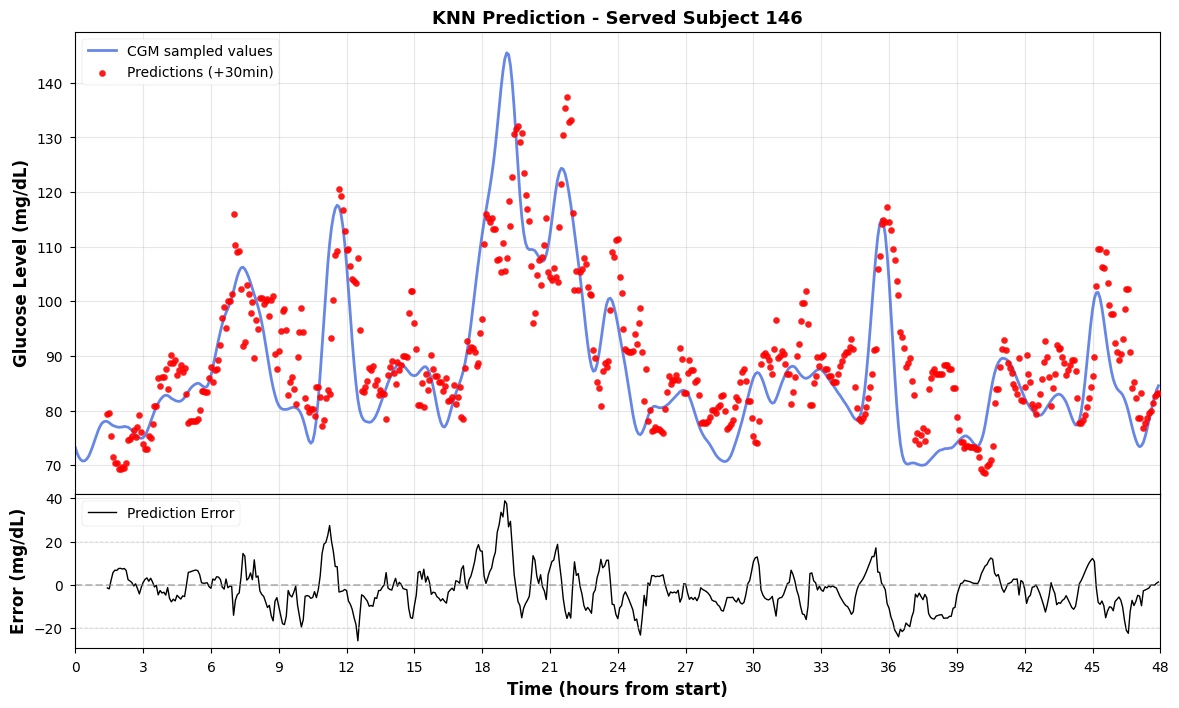

Served Subject 146: Visualization generated.


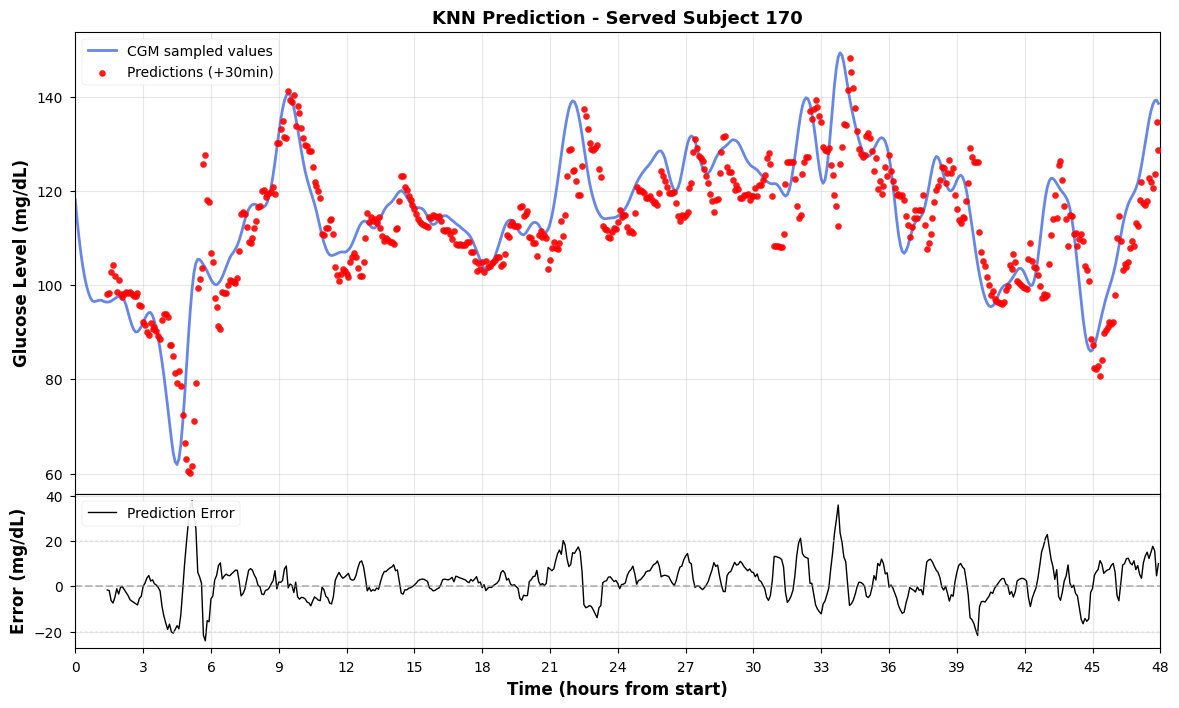

Served Subject 170: Visualization generated.


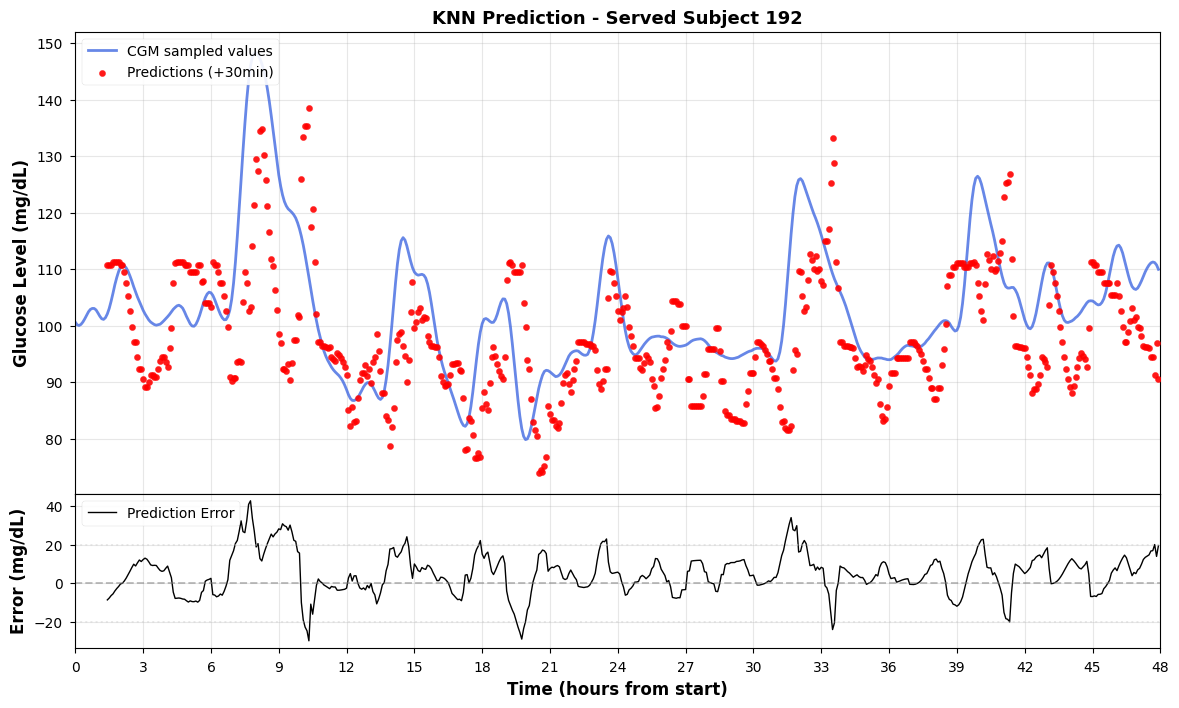

Served Subject 192: Visualization generated.


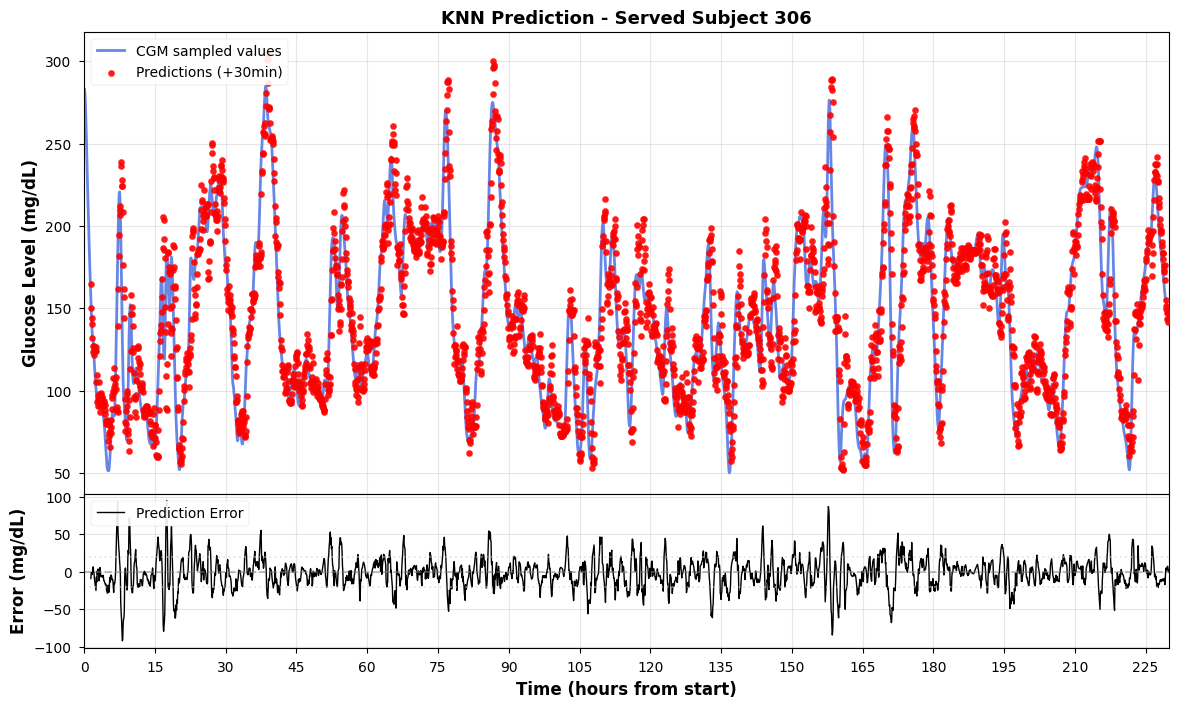

Served Subject 306: Visualization generated.


In [8]:
# --- 新增模块：Served Set (长期预测) 分析 ---

# 1. 加载 Served 数据集
served_path = '../../DataSplit/Served/served.csv'
df_served = pd.read_csv(served_path, parse_dates=['time'])
print(f"Served 数据集加载完成，形状: {df_served.shape}")

# 2. 构建 Served Set 特征和标签
print("正在构建 Served Set 数据集...")
X_served, y_served = create_dataset(df_served, N_PAST, PREDICTION_HORIZON)
print(f"Served Set 样本数: {len(y_served)}")

# 3. 标准化
X_served_scaled = scaler.transform(X_served)

# 4. 预测
print(f"正在对 Served Set 进行预测...")
y_pred_served = knn_model.predict(X_served_scaled)

# 5. 计算评估指标
mae_s, rmse_s, mape_s, rmspe_s = calculate_metrics(y_served, y_pred_served)
print("-" * 30)
print(f"Served Set 评估结果 (Horizon={PREDICTION_HORIZON}):")
print(f"MAE: {mae_s:.4f} mg/dL")
print(f"RMSE: {rmse_s:.4f} mg/dL")
print(f"MAPE: {mape_s:.4f}%")
print(f"RMSPE: {rmspe_s:.4f}%")
print("-" * 30)

# 6. 可视化
subject_ids_served = sorted(df_served['id'].unique())
current_idx_s = 0

for subject_id in subject_ids_served:
    subject_data = df_served[df_served['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    # 计算有效样本数
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    if n_valid <= 0:
        continue
        
    # 提取该受试者的预测值
    y_pred_s = y_pred_served[current_idx_s : current_idx_s + n_valid]
    
    current_idx_s += n_valid
    
    # 对应的时间轴
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    pred_indices = np.arange(N_PAST + PREDICTION_HORIZON - 1, N_PAST + PREDICTION_HORIZON - 1 + n_valid)
    pred_hours = full_hours[pred_indices]
    
    # 真实值
    y_true_s = gl_values[pred_indices]
    
    error_s = y_true_s - y_pred_s
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    ax1.plot(full_hours, gl_values, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_s, label=f'Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'KNN Prediction - Served Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error_s, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    max_hours = np.ceil(full_hours[-1])
    ax2.set_xlim(0, max_hours)
    tick_interval = max(1, int(max_hours / 15)) 
    ax2.xaxis.set_major_locator(plt.MultipleLocator(tick_interval))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    
    plt.show()
    print(f"Served Subject {subject_id}: Visualization generated.")

正在绘制标准 Clarke Error Grid (使用 utils/ceg_utils.py)...


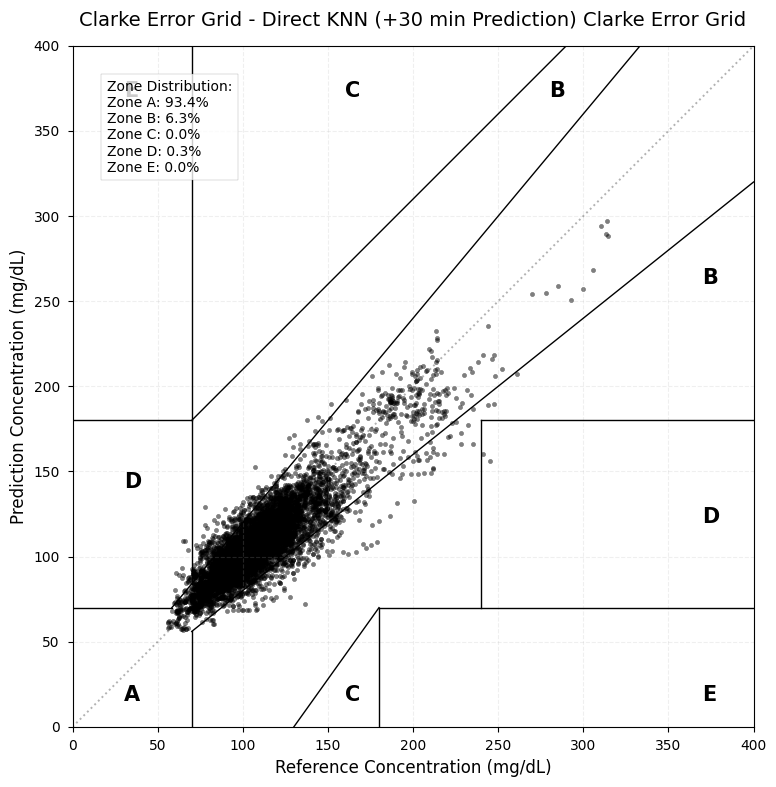


各区临床统计:
  Zone A: 93.39%
  Zone B: 6.30%
  Zone C: 0.00%
  Zone D: 0.31%
  Zone E: 0.00%
  A + B (临床安全): 99.69%


In [9]:
import sys
import os
import importlib

# 添加 utils 目录到系统路径
# 假设当前工作目录是 notebook 所在目录 (src/Prediction/KNN)
# utils 目录在 ../../../utils
utils_path = os.path.abspath('../../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

try:
    import ceg_utils
    importlib.reload(ceg_utils) # 确保加载最新的修改
except ImportError:
    print(f"Error: Could not import ceg_utils from {utils_path}")

# ============ 直接调用 ============
print("=" * 60)
print("正在绘制标准 Clarke Error Grid (使用 utils/ceg_utils.py)...")
print("=" * 60)

# 调用工具函数
# 注意: ceg_utils.clarke_error_grid 返回 (plt对象, 百分比列表)
plt_obj, zones_pct_list = ceg_utils.clarke_error_grid(
    y_test, 
    y_pred, 
    title_string=f"Clarke Error Grid - Direct KNN (+{PREDICTION_HORIZON*5} min Prediction)"
)

plt_obj.show()

# 转换列表为字典以便打印
zones = ['A', 'B', 'C', 'D', 'E']
zones_pct = {z: p for z, p in zip(zones, zones_pct_list)}

print("\n各区临床统计:")
for zone in ['A', 'B', 'C', 'D', 'E']:
    print(f"  Zone {zone}: {zones_pct[zone]:.2f}%")
print(f"  A + B (临床安全): {zones_pct['A'] + zones_pct['B']:.2f}%")